#### *Applied Mathematical Finance 2*

## <ins> *Lab 1: Handling Dividends* </ins>

The deadline is 23:59 on 2nd of April, 2026. The solution must be sent up to the deadline on AppliedMathematicalFinance1@gmail.com.


### 1. Cash Dividend Model naive Monte-Carlo (40 points)

Consider the Cash Dividend Model where the stock price dynamics in-between ex-dividend dates $0 < \tau_1 < \cdots < \tau_n < T$ under the risk-neutral measure $\mathbb{Q}$ is given by


$$dS_t/S_t = rdt + \sigma dW^{\mathbb{Q}}_t, \quad t \in [\tau_{i-1}, \tau_i),$$
$$S_{\tau_{i}-} - S_{\tau_{i}} = d_i.$$

Assume that the initial spot price is $S_0 = 100 \$$, the risk-free interest rate $r=15\%$ and the volatility $\sigma = 25\%$. Also, assume that the stock pays $5\$$ cash dividends in the middle of each year (for the sake of simplicity, assume that there is no dividends payment lag).

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.optimize as opt
import warnings
import py_vollib.black.implied_volatility as iv
warnings.filterwarnings('ignore')
np.random.seed(42)

import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

1. **(5 points)** Compute a forward curve $(F_{0, t})_{t \in [0, T]}$. Your answer should contatin a plot of a forward curve. Assume that $T = 5$ years.

$$F_{t,T} = S_t R(t, T) - \sum_{i=1}^n \alpha_i R(\tau_i, T),$$
$$R(t, T) = e^{\int_t^T (r_s - \mu_s) ds} \prod_{j: t < \tau_j \le T} (1 - \beta_j)$$

В Нашем случае:
$$F_{t,T} = S_t e^{r(T-t)} - \sum_{i=1}^n \alpha_i e^{r(T-\tau_i)}$$





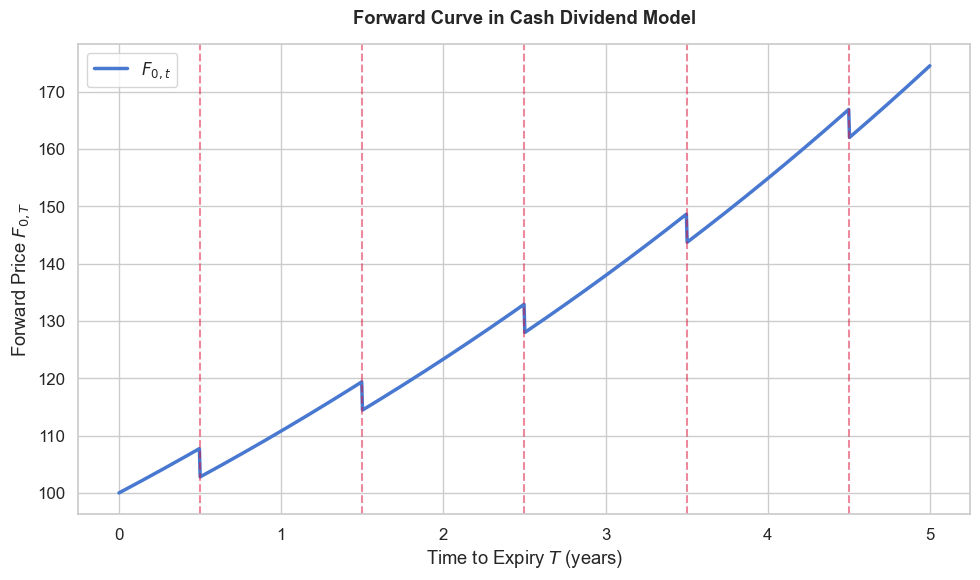

In [21]:
# def forwardPrice(t, T, r, mu, beta, alpha, S_t, tau):
#     mask = (tau > t) & (tau <= T)
#     tau = tau[mask]
#     alpha = alpha[mask]
#     beta = beta[mask]

#     def R(start, end):
#         contPart = np.exp((r - mu) * (end - start))    
        
#         if isinstance(start, np.ndarray):
#             discPart = np.array([
#                 np.prod(1 - beta[(tau > s) & (tau <= end)]) 
#                 for s in start
#             ])
#         else:   
#             discPart = np.prod(1 - beta[(tau > start) & (tau <= end)])
          
#         return contPart * discPart

#     return S_t * R(t, T) - np.sum(alpha * R(tau, T))

def forwardPrice(St, r, t, T, alpha, tau):
    contPart=St*np.exp(r*(T-t))

    discPart = 0
    i=0
    for tt, a in zip(tau, alpha):
        if t < tt <= T:
            discPart += a * np.exp(r * (T - tt))        
            i+=1

    return (contPart - discPart)

S0 = 100.0
r = 0.15
d = 5.0
T = 5.0

tauDivs = np.array([0.5, 1.5, 2.5, 3.5, 4.5])
alphas = np.array([5.0]*5) 
betas = np.zeros(5) 

tGrid = np.linspace(0, T, 1000)


FCurve = [
    # forwardPrice(t=0, T=TVal, r=r, mu=0, beta=betas, alpha=alphas, S_t=S0, tau=tauDivs) 
    forwardPrice(t=0, T=TVal, r=r, alpha=alphas, St=S0, tau=tauDivs) 
    for TVal in tGrid
]

fFinal = FCurve[-1]  

# plt.figure(figsize=(10, 6))
# plt.plot(tGrid, FCurve, color='blue', linewidth=2, label='$F_{0, t}$')

# for tau in tauDivs:
#     plt.axvline(x=tau, color='red', linestyle='--', alpha=0.4)

# plt.title('Forward Curve')
# plt.xlabel('$T$ (years)')
# plt.ylabel('Forward Price $F_{0, T}$')
# plt.grid(True, linestyle=':', alpha=0.7)
# plt.legend()
# plt.show()


plt.figure(figsize=(10, 6))

sns.lineplot(x=tGrid, y=FCurve, color='b', linewidth=2.5, label='$F_{0, t}$')

for tau in tauDivs:
    plt.axvline(x=tau, color='crimson', linestyle='--', alpha=0.5)

# plt.xlim(1.4, 1.6)

plt.title('Forward Curve in Cash Dividend Model', pad=15, fontweight='bold')
plt.xlabel('Time to Expiry $T$ (years)')
plt.ylabel('Forward Price $F_{0, T}$')
plt.legend()
plt.tight_layout() 
plt.show()

In [22]:
print("=" * 65)
print(f"{'Sanity Check: Forward Price Jumps':^65}")
print("=" * 65)
print(f"{'Ex-Date (years)':^17} | {'F before ($)':^13} | {'F after ($)':^13} | {'Jump ($)':^10}")
print("-" * 65)

for tau in tauDivs:
    FBefore = forwardPrice(S0, r, 0, tau - 1e-10, alphas, tauDivs)
    FAfter = forwardPrice(S0, r, 0, tau + 1e-10, alphas, tauDivs)
    jump = FBefore - FAfter
    
    print(f"{tau:10.1f} {'':<6}| {FBefore:11.4f} {'':<1}| {FAfter:11.4f} {'':<1}| {jump:8.4f}")

print("=" * 65)

                Sanity Check: Forward Price Jumps                
 Ex-Date (years)  | F before ($)  |  F after ($)  |  Jump ($) 
-----------------------------------------------------------------
       0.5       |    107.7884  |    102.7884  |   5.0000
       1.5       |    119.4231  |    114.4231  |   5.0000
       2.5       |    132.9407  |    127.9407  |   5.0000
       3.5       |    148.6459  |    143.6459  |   5.0000
       4.5       |    166.8927  |    161.8927  |   5.0000


2. **(15 points)** Using the Monte-Carlo method method, obtain the prices of vanilla options (in terms of Black implied volatilities) with maturity $T=5$ years. Use the strikes $K$ ranging from $40$ to $160$ with step $5$. Your answer should contain an implied volatilities curve plot.

Все страйки $<F_{0,T}$, поэтому будем строить через путы (чтобы OTM построение обеспечить)

In [23]:
def black(fPrice: float, K: float, vol: float, T: float, r: float, isCall: bool) -> float:
    """
    Args:
        fPrice: форвардная цена (F).
        K: цена исполнения (K).
        vol: подразумеваемая волатильность (sigma).
        T: время до экспирации (T).
        r: безрисковая ставка (r).
        isCall: тип опциона (True если Call, False если Put).
    """

    d1 = (np.log(fPrice / K) + 0.5 * vol**2 * T) / (vol * np.sqrt(T))
    d2 = d1 - vol * np.sqrt(T)

    theta = 1.0 if isCall else -1.0

    discount = np.exp(-r * T)
    price = theta * discount * (fPrice * norm.cdf(theta * d1) - K * norm.cdf(theta * d2))
    
    return price

In [24]:
def stockDynamic(S0, r=0.15, sigma=0.25, nSims=10_000, T=5, seed=42):
    
    if seed is not None:
        np.random.seed(seed)
        
    stepsPerYear = 252     # Количество шагов в году
    nSteps = int(T * stepsPerYear)
    dt = T / nSteps

    # сетка времени для симуляции 
    tSim = np.linspace(0, T, nSteps + 1)
    sMatrix = np.zeros((nSteps + 1, nSims))
    sMatrix[0] = S0

    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)

    for i in range(1, nSteps + 1):
        tPrev = tSim[i - 1]
        tCurr = tSim[i]
        
        Z = np.random.standard_normal(nSims)
        sMatrix[i] = sMatrix[i - 1] * np.exp(drift + vol * Z)
        
        # скачки: если прошли через дату дивиденда, вычитаем его
        for tau in tauDivs:
            if tPrev < tau <= (tCurr + 1e-6):
                sMatrix[i] = np.maximum(sMatrix[i] - d, 1e-4)

    return sMatrix

def getMcPutPrice(K, r = 0.15, sigma = 0.25, nSims = 10_000, T = 5):
    
    sMatrix = stockDynamic(r, sigma, nSims, T)
    sFinal = sMatrix[-1] 
    payoffs = np.maximum(K - sFinal, 0)
    put_price = np.exp(-r * T) * np.mean(payoffs)
    
    return put_price

    
sMatrix = stockDynamic(S0, r = 0.15, sigma = 0.25, nSims = 2**17, T = 5)
sFinal = sMatrix[-1]
stepsPerYear = 252     # Количество шагов в году
nSteps = int(T * stepsPerYear)
dt = T / nSteps

# сетка времени для симуляции 
tSim = np.linspace(0, T, nSteps + 1)

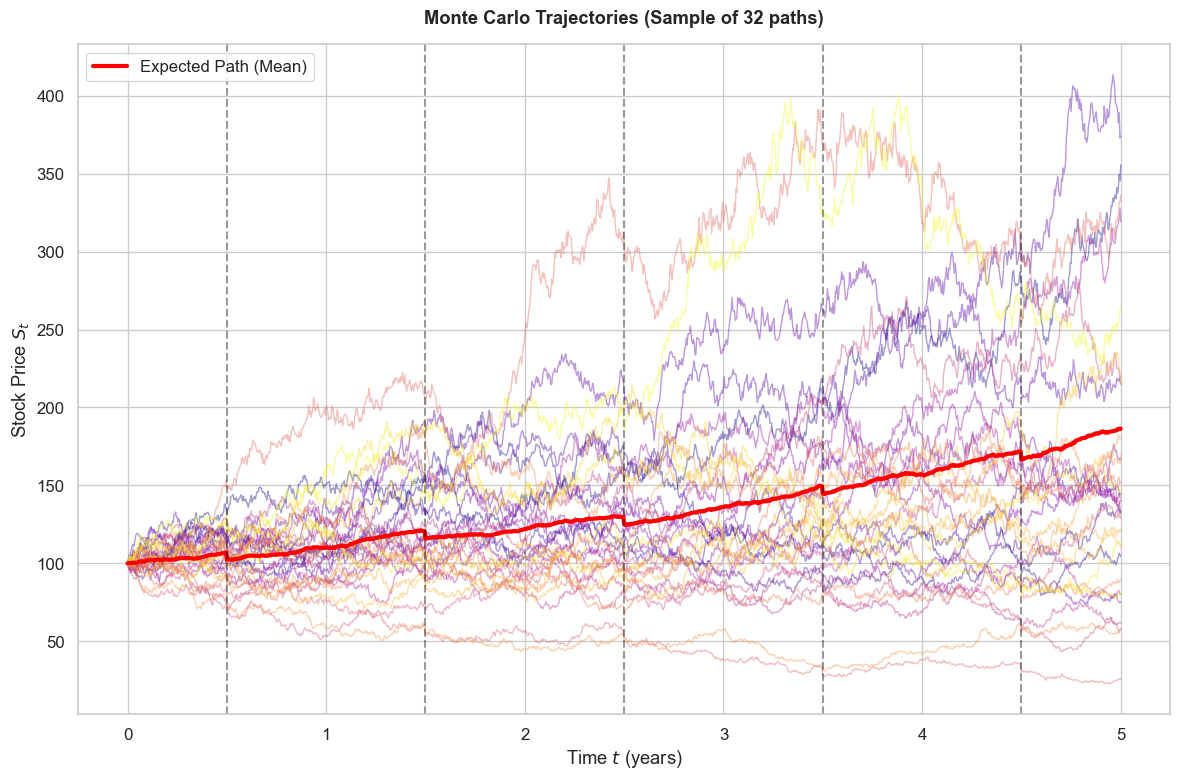

In [25]:
plt.figure(figsize=(12, 8))

cmap = plt.cm.plasma   
colors = cmap(np.linspace(0, 1, 32))

for i in range(32):
    plt.plot(tSim, sMatrix[:, i], color=colors[i], alpha=0.4, linewidth=1)

expectedPath = np.mean(sMatrix[:, :128], axis=1)
# expectedPath = np.mean(sMatrix, axis=1)
sns.lineplot(x=tSim, y=expectedPath, color='red', linewidth=3, label='Expected Path (Mean)')

for tau in tauDivs:
    plt.axvline(x=tau, color='black', linestyle='--', alpha=0.4)

# это чтобы увидеть, что красная линия -- не прямая:
# plt.xlim(1.4,1.6)
# plt.ylim(120,140)


plt.title('Monte Carlo Trajectories (Sample of 32 paths)', pad=15, fontweight='bold')
plt.xlabel('Time $t$ (years)')
plt.ylabel('Stock Price $S_t$')
plt.legend()
plt.tight_layout()
plt.show()

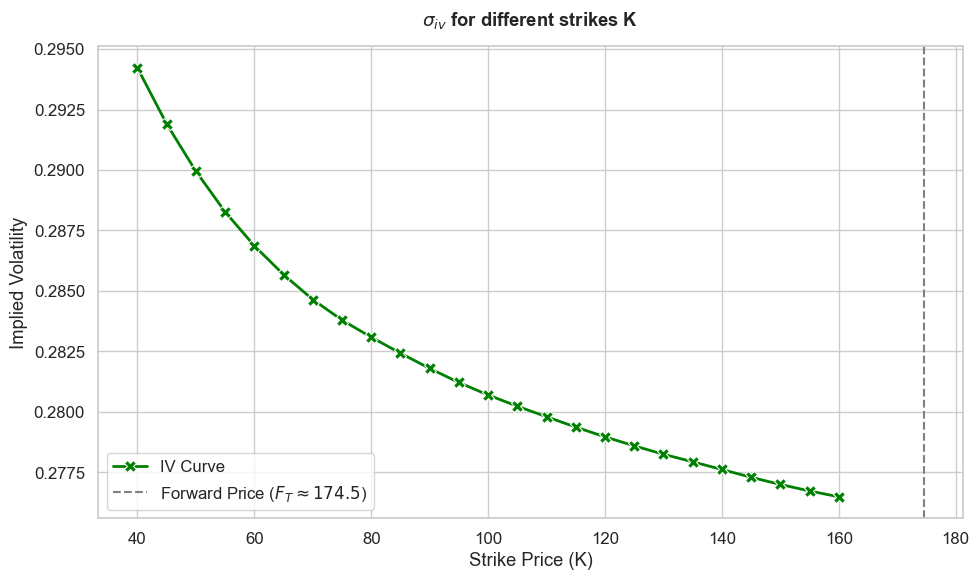

In [26]:
strikePrices = np.arange(40, 165, 5)

fFinal = forwardPrice(St=S0, r=r, t=0, T=T, alpha=alphas, tau=tauDivs)

mcPrices = []
impliedVols = []

for currentStrike in strikePrices:
    # считаем цену PUT-опциона по Монте-Карло
    payoffs = np.maximum(currentStrike - sFinal, 0)
    putPrice = np.exp(-r * T) * np.mean(payoffs)
    mcPrices.append(putPrice)
    
  
    vol = iv.implied_volatility(putPrice, fFinal, currentStrike, r, T, "p")
    impliedVols.append(vol)



plt.figure(figsize=(10, 6))
sns.lineplot(x=strikePrices, y=impliedVols, color='green', marker='X', markersize=8, linewidth=2, label='IV Curve')

plt.axvline(x=fFinal, color='gray', linestyle='--', label=f'Forward Price ($F_T \\approx {fFinal:.1f}$)')

plt.title("$\sigma_{iv}$ for different strikes K", pad=15, fontweight='bold')
plt.ylabel("Implied Volatility")
plt.xlabel("Strike Price (K)")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# def convexity_arbitrage(c: np.ndarray, k: np.ndarray):
#     arbitrage_detected = False
#     for i in range(1, len(c) - 1):
#         check_to = c[i-1] / (k[i] - k[i-1]) - c[i] * (1/(k[i] - k[i-1]) + 1/(k[i+1] - k[i])) + c[i+1] / (k[i+1] - k[i]) 
#         if check_to < 0:
#             print("A convexity arbitrage was detected with strikes {}, {} and {}".format(k[i-1], k[i], k[i+1]))
#             arbitrage_detected = True

#     if not arbitrage_detected:
#         print("No arbitrage was detected.")


# convexity_arbitrage(np.array(mcPrices), strikePrices)

3. **(10 points)** Show that your Monte-Carlo algorithm converges in terms of decreasing empirical (relative) error when the number of simulations increases. Your answer should contain a plot of error as a function of number of simulations.


N =     16 | Относит. ошибка = 59.3684%
N =     32 | Относит. ошибка = 36.7359%
N =     64 | Относит. ошибка = 29.8322%
N =    128 | Относит. ошибка = 18.8843%
N =    256 | Относит. ошибка = 12.2365%
N =    512 | Относит. ошибка = 8.9242%
N =   1024 | Относит. ошибка = 6.2618%
N =   2048 | Относит. ошибка = 4.4418%
N =   4096 | Относит. ошибка = 3.2098%
N =   8192 | Относит. ошибка = 2.2831%
N =  16384 | Относит. ошибка = 1.6211%
N =  32768 | Относит. ошибка = 1.1480%
N =  65536 | Относит. ошибка = 0.8012%
N = 131072 | Относит. ошибка = 0.5689%


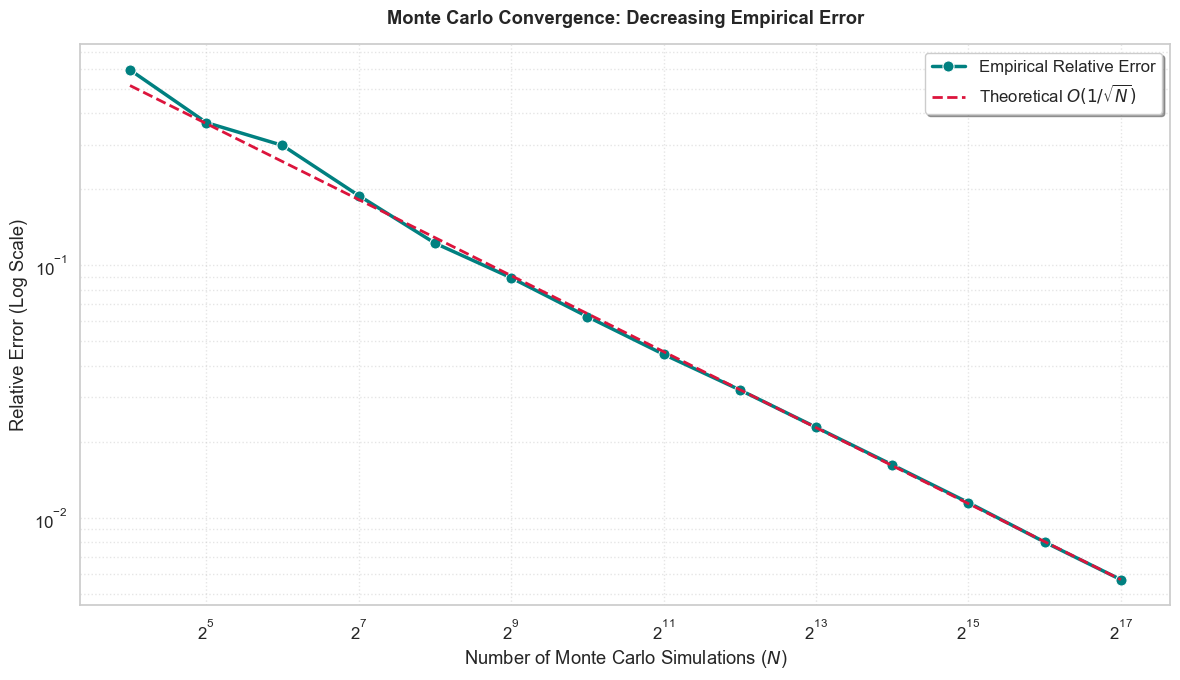

In [28]:
numSimulationsRange = np.array([2**i for i in range(4, 18)]) 
KTest = 100.0 

relativeErrors = []

for nSims in numSimulationsRange:
    sMatrix = stockDynamic(S0, r=r, sigma=0.25, nSims=nSims, T=T)
    sFinal = sMatrix[-1]
    
    payoffs = np.maximum(KTest - sFinal, 0)
    discountedPayoffs = np.exp(-r * T) * payoffs
    
    putPrice = np.mean(discountedPayoffs)
    stdDev = np.std(discountedPayoffs, ddof=1)
    standardError = stdDev / np.sqrt(nSims)
    
    # Относительная ошибка = (Стандартная ошибка) / (Цена)
    relError = standardError / putPrice if putPrice > 0 else 0
    relativeErrors.append(relError)
    
    print(f"N = {nSims:6d} | Относит. ошибка = {relError:.4%}")

plt.figure(figsize=(12, 7))

sns.lineplot(
    x=numSimulationsRange, 
    y=relativeErrors, 
    marker='o', 
    markersize=8,
    color='teal', 
    linewidth=2.5, 
    label='Empirical Relative Error'
)

# theoreticalLine = relativeErrors[0] * (np.sqrt(numSimulationsRange[0]) / np.sqrt(numSimulationsRange))
theoreticalLine = relativeErrors[-1] * (np.sqrt(numSimulationsRange[-1]) / np.sqrt(numSimulationsRange))
sns.lineplot(
    x=numSimulationsRange, 
    y=theoreticalLine, 
    linestyle='--', 
    color='crimson', 
    linewidth=2, 
    label=r'Theoretical $O(1/\sqrt{N})$'
)

plt.xscale('log', base=2) 
plt.yscale('log') 
plt.title('Monte Carlo Convergence: Decreasing Empirical Error', pad=15, fontweight='bold')
plt.xlabel('Number of Monte Carlo Simulations ($N$)')
plt.ylabel('Relative Error (Log Scale)')

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

4. **(10 points)** As a sanity check of your simulations algorithm, show that the empirically averaged stock sprice $S_T$ converges to a forward price $F_{0, T}$ when number of monte carlo simulations increases.

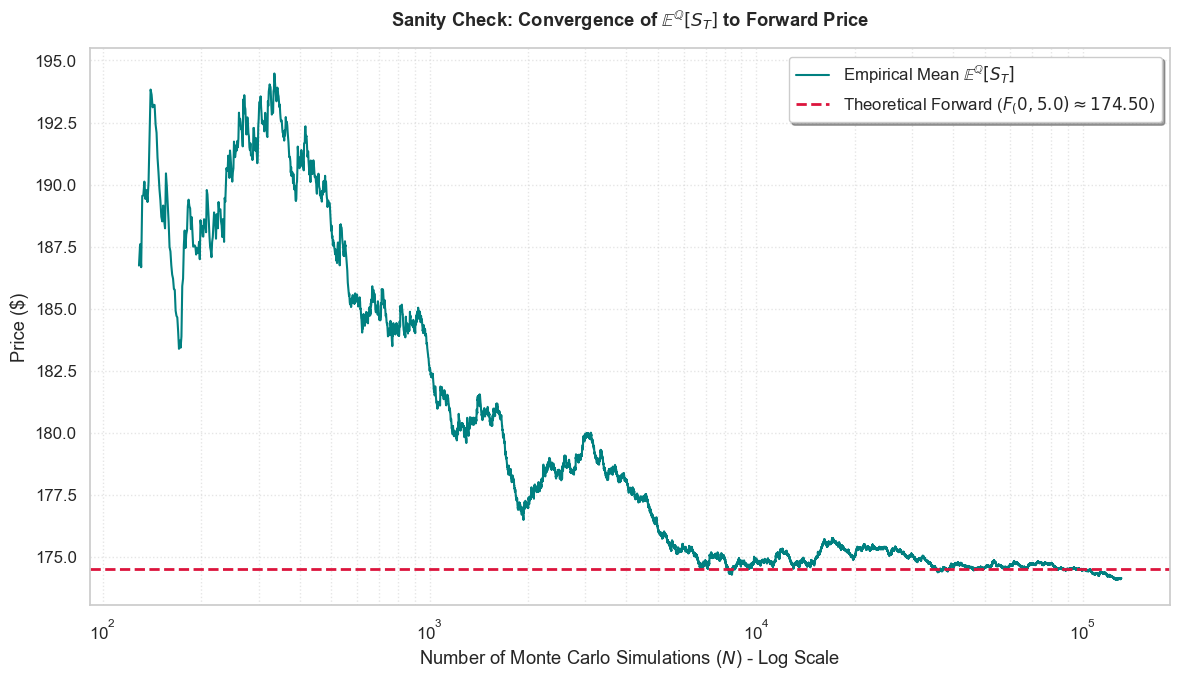

In [29]:
nSims = 2**17
# nSims = np.array([2**i for i in range(4, 19)])


S = stockDynamic(S0, r = 0.15, sigma = 0.25, nSims = nSims, T = 5, seed = 42)

# for n in range (nSims):
#     stockPrice.append(S[-1,n])
stockPrice = S[-1]

stockPriceCumSum = np.cumsum(stockPrice)
nValues = np.arange(1, nSims + 1)
meanStockPrice = stockPriceCumSum / nValues



plt.figure(figsize=(12, 7))

sns.lineplot(
    x=nValues[128:], 
    y=meanStockPrice[128:], 
    color='teal', 
    linewidth=1.5, 
    label='Empirical Mean $\mathbb{E}^{\mathbb{Q}}[S_T]$'
)

plt.axhline(
    y=fFinal, 
    color='crimson', 
    linestyle='--', 
    linewidth=2, 
    label=f'Theoretical Forward ($F_{0,T} \\approx {fFinal:.2f}$)'
)

plt.xscale('log')

plt.title('Sanity Check: Convergence of $\mathbb{E}^{\mathbb{Q}}[S_T]$ to Forward Price', pad=15, fontweight='bold')
plt.xlabel('Number of Monte Carlo Simulations ($N$) - Log Scale')
plt.ylabel('Price ($)')

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### 2. Cash Dividend Model approximations (60 points)

Using option prices obtained in the problem above, compute implied volatilities corresponding to each of the following affine approximations of the Cash Dividend Model.  Each of your answers should contain an implied volatilities curve plot.

For each model, make your conclusion about the quality of the approximation. What happens with the implied volatility when the valuation date passes the ex-dividend date? When the option's expiry date passes the ex-div date?

1. **(15 points)** **Forward (Black) model**

$$PV^{MC} = P(0,T) \times Black(F_{0,T}, K, \sigma_{FWD}, T)$$
$$\tilde{S_t} = S_t - PV_{0,T}^{\text{fut divs}}$$
$$PV_{t,u}^{\text{fut divs}} = \sum_{i:\tau_i \in (t,u]} d_i e^{-r(\tau_i - t)}$$
$$S_T = F_{0,T} \cdot e^{-\frac{1}{2} \sigma^2 T + \sigma W_T^{\mathbb{Q}}} = [S_0 - PV_{0,T}^{\text{fut divs}}]e^{rT}Z_T$$
$$PV_0 = P(0, T) \cdot \text{Black}(g(T), K - h(T), \sigma, T),$$
$$PV_0 = P(0, T) \cdot \text{Black}([S_0 - PV_{0,T}^{\text{fut divs}}]e^{rT}, K , \sigma, T),$$


In [30]:
def PVFutDivs(d, tau, r, t, u):
    tauInd = (tau>t) & (tau<=u)
    tau = tau[tauInd]
    d = d[tauInd]
    
    PV = 0
    for tt,dd in zip(tau, d):
        PV += dd * np.exp(-r*(tt-t)) 
    return PV

# def PVPastDivs(PVFut,r, T):
#     return PVFut *np.exp(r*T)


def PVPasttDivs(d, tau, r, t, s):
    tauInd = (tau>s) & (tau<=t)
    tau = tau[tauInd]
    d = d[tauInd]
    
    PV = 0
    for tt,dd in zip(tau, d):
        PV += dd * np.exp(r*(t-tt)) 
    return PV


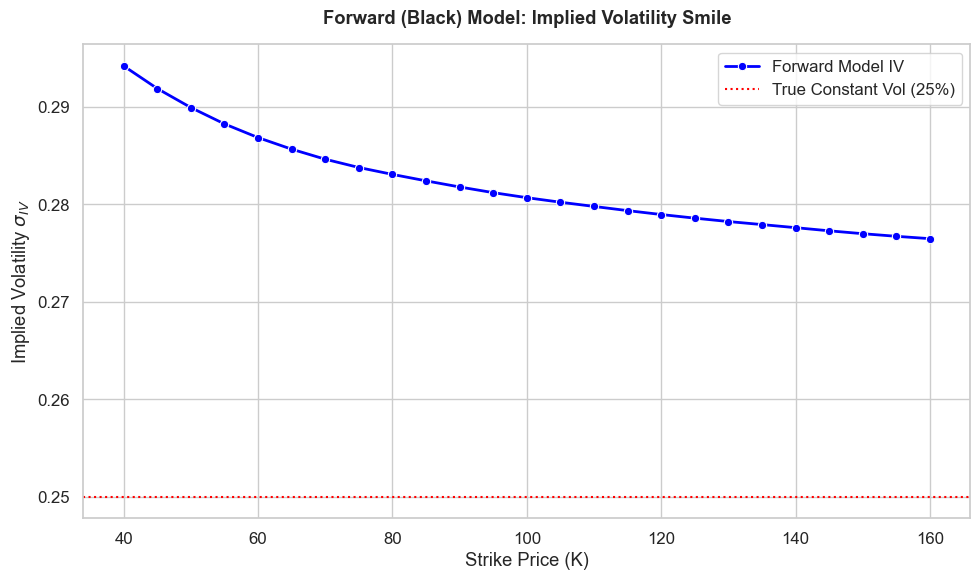

In [31]:
pvDivsFut = PVFutDivs(d=alphas, tau=tauDivs, r=0.15, t=0, u=T)
S0_ = S0 - pvDivsFut
F_ = S0_ * np.exp(r * T)
impliedVols_FWD = []

for currentStrike, putPrice in zip(strikePrices, mcPrices):
    vol = iv.implied_volatility(putPrice, F_, currentStrike, r, T, "p")
    impliedVols_FWD.append(vol)


plt.figure(figsize=(10, 6))
sns.lineplot(x=strikePrices, y=impliedVols_FWD, color='blue', marker='o', markersize=6, linewidth=2, label='Forward Model IV')

# plt.axvline(x=F_, color='gray', linestyle='--', label=f'Forward Price ($F_T \\approx {F_:.2f}$)')
plt.axhline(y=0.25, color='red', linestyle=':', label='True Constant Vol (25%)')

plt.title("Forward (Black) Model: Implied Volatility Smile", pad=15, fontweight='bold')
plt.ylabel("Implied Volatility $\sigma_{IV}$")
plt.xlabel("Strike Price (K)")
plt.legend()
plt.tight_layout()
plt.show()

### Недостатки Forward Model:

Проблема смещения даты экспирации ($T \to \tau$): Форвардная модель предполагает, что базовая цена за вычетом всех будущих дивидендов ведет себя логнормально.  
Недостаток: Главное требование модели Блэка — базовый актив в момент экспирации $T$ должен иметь строго логнормальное распределение. Если мы фиксируем дату оценки $t$, но начинаем двигать дату экспирации опциона $T$, то в момент, когда $T$ переваливает через ex-dividend date $\tau$, из базового актива скачкообразно вычитается новый дивиденд.

Форвардная цена резко падает. Если мы оставим подразумеваемую волатильность неизменной, теоретическая цена опциона тоже испытает разрыв. Но цены опционов непрерывны по времени экспирации. Чтобы скомпенсировать скачок форварда и сохранить цену гладкой, подразумеваемая волатильность $\sigma_{FWD}$ вынуждена совершить скачок. Это делает невозможной интерполяцию IV вдоль временной структуры.

2. **(20 points)** **Spot model**

$$\tilde{S_t} = S_t + PV_{0,T}^{past divs}$$
$$PV_{s,t}^{\text{past divs}} = \sum_{i:\tau_i \in (s,t]} d_i e^{r(t - \tau_i)}$$


$$\tilde{S}_0 = S_0$$
$$S_T = S_0 e^{rT} e^{-\frac{1}{2}\sigma^2 T + \sigma W_T^{\mathbb{Q}}} - PV_{0,T}^{\text{past divs}}$$

<!-- $$S_T = \underbrace{S_0 e^{rT}}_{g} Z_T \underbrace{- e^{rT} PV_{0,T}^{\text{future divs}}}_{h}$$ -->

$$\text{Payoff} = (K - (\tilde{S}_T - PV_{past}))_+ = ((K + PV_{past}) - \tilde{S}_T)_+$$


$$PV_0 = P(0, T) \cdot \text{Black}(g(T), K - h(T), \sigma, T),$$
$$PV_0 = P(0, T) \cdot \text{Black}(S_0 e^{rT}, K + PV_{past} , \sigma, T),$$


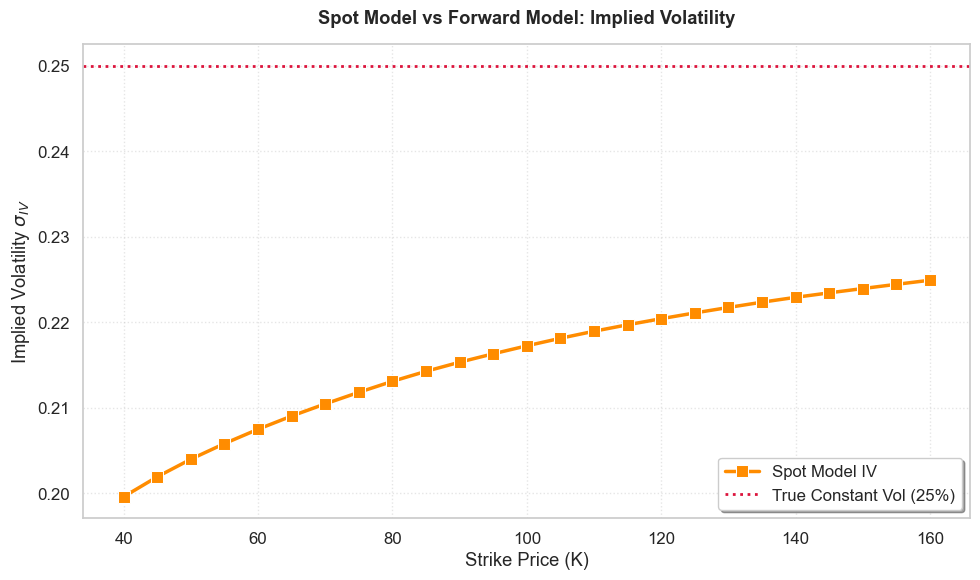

In [32]:

pvDivsPast = PVPasttDivs(d=alphas, tau=tauDivs, r=0.15, t=T, s=0)
F = S0 * np.exp(r * T)


impliedVolsSpot = []

for currentStrike, putPrice in zip(strikePrices, mcPrices):

    # Передаем F = S0 * np.exp(r * T) и K = currentStrike - pvDivsPast
    vol = iv.implied_volatility(putPrice, F, currentStrike + pvDivsPast, r, T, 'p')
    impliedVolsSpot.append(vol)

plt.figure(figsize=(10, 6))


sns.lineplot(x=strikePrices, y=impliedVolsSpot, color='darkorange', marker='s', 
             markersize=8, linewidth=2.5, label='Spot Model IV')

# plt.axvline(x=F, color='gray', linestyle='--', label=f'True Forward ($F_T \\approx {F:.2f}$)')
plt.axhline(y=0.25, color='crimson', linestyle=':', linewidth=2, label='True Constant Vol (25%)')

plt.title("Spot Model vs Forward Model: Implied Volatility", pad=15, fontweight='bold')
plt.ylabel("Implied Volatility $\\sigma_{IV}$")
plt.xlabel("Strike Price (K)")

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### Недостатки Spot Model: 

Проблема смещения даты оценки ($t \to \tau$): Модель считает логнормальным весь спот (плюс прошлые дивиденды), вычитая влияние дивидендов детерминированно в самом конце.  
Цена опциона должна быть непрерывна при переходе текущей даты $t$ через дату отсечки $\tau$. То есть $PV(\tau-, S_{\tau-}) = PV(\tau, S_{\tau-} - d)$.   
В момент отсечки спот-цена акции на рынке падает на величину дивиденда $d$. Поскольку Spot-модель применяет единую волатильность ко всей базе, резкое изменение спота требует изменения самой волатильности, чтобы формула Блэка выдала ту же самую справедливую цену, что и секунду назад. Следовательно, каждый раз, когда отрывается купон дивиденда, $\sigma_{SPOT}$ совершает скачок.

3. **(25 points)** **Bos-Vandermark model**


$$
\begin{aligned}
PV_{0,T}^\text{near divs} &= \sum\limits_{i:\, \tau_i \in (0, T]} \frac{T - \tau_i}{T} d_i e^{-r \tau_i}\\
PV_{0,T}^\text{far divs} &= \sum\limits_{i:\, \tau_i \in (0, T]} \frac{\tau_i}{T} d_i e^{-r \tau_i} = PV_{0,T}^\text{future divs} - PV_{0,T}^\text{near divs}
\end{aligned}
$$

$$S_T = [S_0 - PV_{0,T}^\text{near divs}] e^{rT}Z_T - e^{rT} PV_{0,T}^\text{far divs}$$

$$PV_0 = P(0, T) \cdot \text{Black}(g(T), K - h(T), \sigma, T),$$

$$g(T) = \left[S_0 - PV_{0,T}^\text{near divs}\right] e^{r T}$$

$$h(T) = -e^{rT} PV_{0,T}^\text{far divs}$$



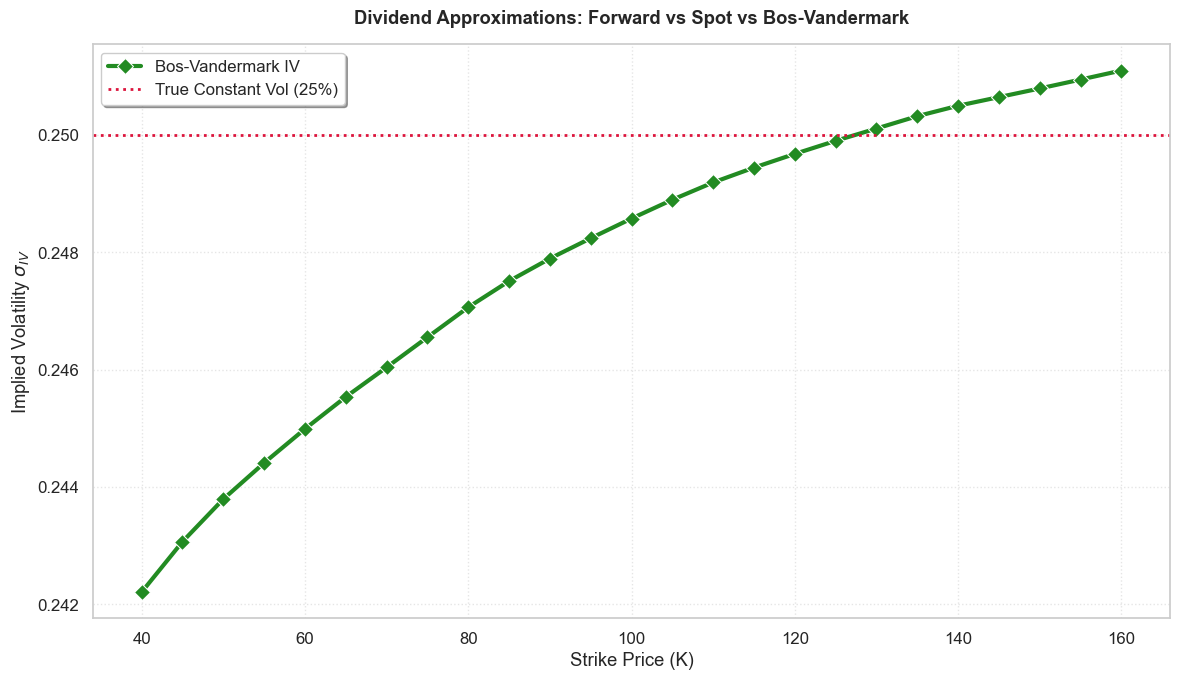

In [33]:
def PVNearDivs(tau, d, u, t, r):
    tauInd = (tau>t) & (tau<=u)
    tau = tau[tauInd]
    d = d[tauInd]
    
    PV = 0
    for tt,dd in zip(tau, d):
        weight = (u-tt)/(u-t)
        PV += weight * dd * np.exp(-r*(tt-t)) 
    return PV

def PVFarDivs(tau, d, u, t, r):
    tauInd = (tau>t) & (tau<=u)
    tau = tau[tauInd]
    d = d[tauInd]
    
    PV = 0
    for tt,dd in zip(tau, d):
        weight = (tt - t)/(u-t)
        PV += weight * dd * np.exp(-r*(tt-t)) 
    return PV


pvNearDivs = PVNearDivs(tau = tauDivs, d = alphas, u = T, t = 0, r = 0.15)
pvFarDivs = PVFarDivs(tau = tauDivs, d = alphas, u=T, t=0, r=0.15)

F_ = (S0 - pvNearDivs) *  np.exp(r*T)


impliedVolsBvm = []

for currentStrike, putPrice in zip(strikePrices, mcPrices):

    vol = iv.implied_volatility(putPrice, F_, currentStrike + np.exp(r*T)*pvFarDivs, r=r, t=T, flag='p')
    impliedVolsBvm.append(vol)



plt.figure(figsize=(12, 7))


sns.lineplot(x=strikePrices, y=impliedVolsBvm, color='forestgreen', marker='D', 
             markersize=8, linewidth=3, label='Bos-Vandermark IV')

# plt.axvline(x=fFinal, color='gray', linestyle='--', label=f'True Forward ($F_T \\approx {fFinal:.2f}$)')
plt.axhline(y=0.25, color='crimson', linestyle=':', linewidth=2, label='True Constant Vol (25%)')

plt.title("Dividend Approximations: Forward vs Spot vs Bos-Vandermark", pad=15, fontweight='bold')
plt.ylabel("Implied Volatility $\\sigma_{IV}$")
plt.xlabel("Strike Price (K)")

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### Proxy Cash Dividend Model:
 Разделяя дивиденды на ближние и дальние с помощью весов, зависящих от времени избавляемся от проблем: 
 
 При $t \to \tau$ вес дивиденда полностью переходит в $PV^{near}$, сглаживая переход даты оценки (решает проблему Spot).
 
 При $T \to \tau$ вес дивиденда полностью переходит в $PV^{far}$, сглаживая переход даты экспирации (решает проблему Forward).

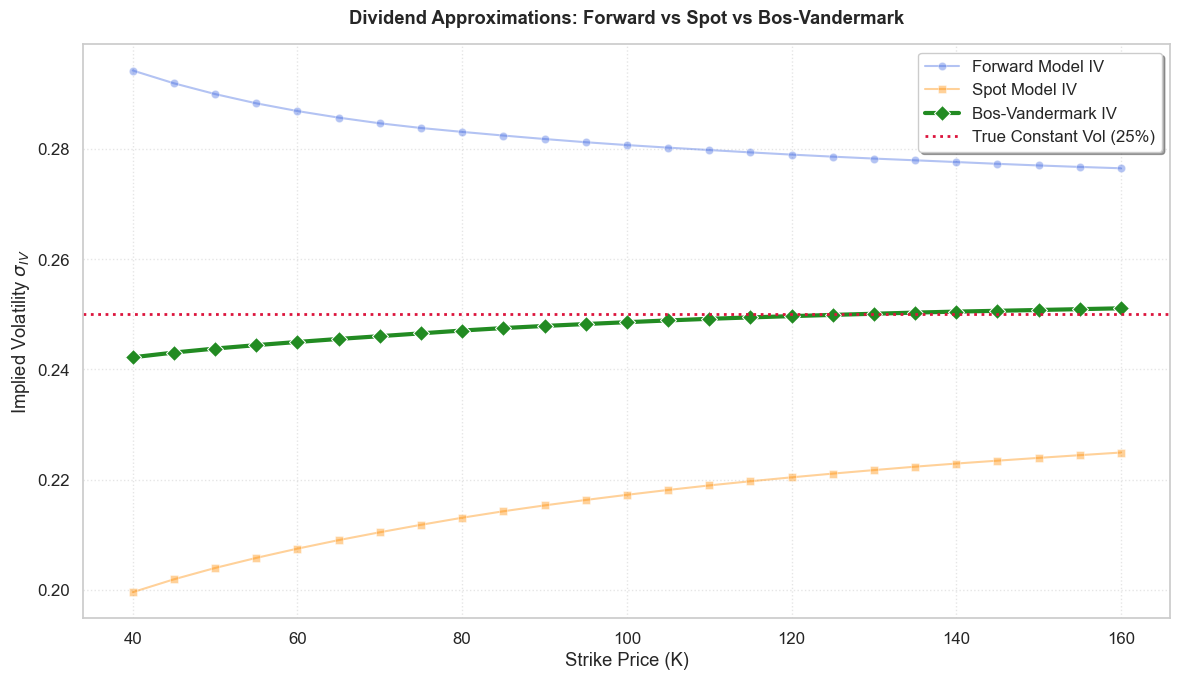

In [34]:
plt.figure(figsize=(12, 7))

# Forward Model (Синяя)
sns.lineplot(x=strikePrices, y=impliedVols_FWD, color='royalblue', marker='o', 
             markersize=6, linewidth=1.5, alpha=0.4, label='Forward Model IV')

# Spot Model (Оранжевая)
sns.lineplot(x=strikePrices, y=impliedVolsSpot, color='darkorange', marker='s', 
             markersize=6, linewidth=1.5, alpha=0.4, label='Spot Model IV')

# Bos-Vandermark Model (Зеленая)
sns.lineplot(x=strikePrices, y=impliedVolsBvm, color='forestgreen', marker='D', 
             markersize=8, linewidth=3, label='Bos-Vandermark IV')

# plt.axvline(x=fFinal, color='gray', linestyle='--', label=f'True Forward ($F_T \\approx {fFinal:.2f}$)')
plt.axhline(y=0.25, color='crimson', linestyle=':', linewidth=2, label='True Constant Vol (25%)')

plt.title("Dividend Approximations: Forward vs Spot vs Bos-Vandermark", pad=15, fontweight='bold')
plt.ylabel("Implied Volatility $\\sigma_{IV}$")
plt.xlabel("Strike Price (K)")

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

#### Дальше идут всякие картинки, демонстрирующие скачки (или же их отсутствие)

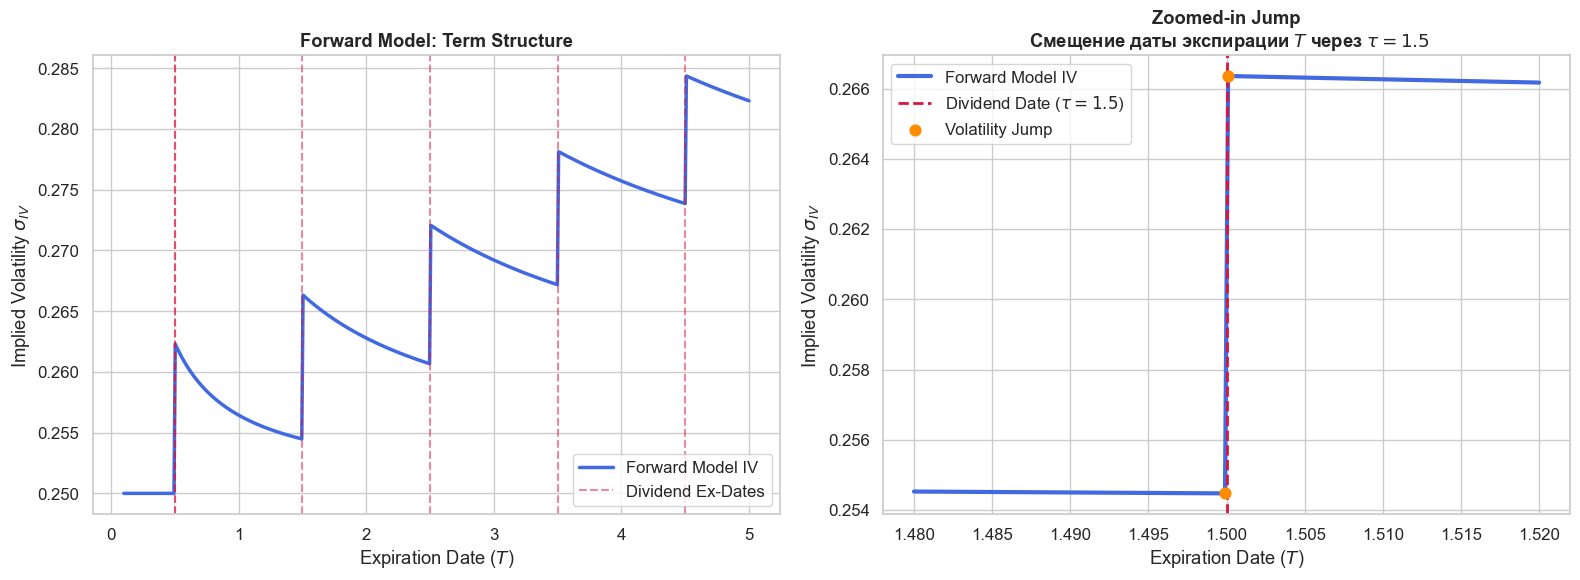

In [35]:
S0 = 100.0
K = 100.0
r = 0.15
d = 5.0
sigmaTrue = 0.25
tauDivs = np.array([0.5, 1.5, 2.5, 3.5, 4.5]) # Даты всех дивидендов

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


tGridFull = np.linspace(0.1, 5.0, 500)
ivForwardFull = []

for tExp in tGridFull:
    pvNear = 0.0
    pvFar = 0.0
    pvFutFwd = 0.0
    
    # Пробегаемся по всем дивидендам, которые попадают до даты экспирации
    for tau in tauDivs:
        if tau <= tExp:
            # Bos-Vandermark
            wNear = (tExp - tau) / tExp
            wFar = tau / tExp
            pvNear += wNear * d * np.exp(-r * tau)
            pvFar += wFar * d * np.exp(-r * tau)
        
            # Для Forward Model
            pvFutFwd += d * np.exp(-r * tau)
            
    # цена из третьей модели Bos-Vandermark
    g = (S0 - pvNear) * np.exp(r * tExp)
    h = -np.exp(r * tExp) * pvFar
    truePrice = black(g, K - h, sigmaTrue, tExp, r, isCall=False)
    
    # Forward Model
    fFwd = (S0 - pvFutFwd) * np.exp(r * tExp)
    
    try:
        vol = iv.implied_volatility(truePrice, fFwd, K, r, tExp, 'p')
        ivForwardFull.append(vol)
    except:
        ivForwardFull.append(np.nan)

ax1.plot(tGridFull, ivForwardFull, color='royalblue', lw=2.5, label='Forward Model IV')
for tau in tauDivs:
    ax1.axvline(x=tau, color='crimson', linestyle='--', alpha=0.5)

ax1.axvline(x=tauDivs[0], color='crimson', linestyle='--', alpha=0.5, label='Dividend Ex-Dates')

ax1.set_title("Forward Model: Term Structure", fontweight='bold')
ax1.set_xlabel("Expiration Date ($T$)")
ax1.set_ylabel("Implied Volatility $\sigma_{IV}$")
ax1.legend()


# разрыв вблизи tau = 1.5
targetTau = 1.5
tGridZoom = np.linspace(1.48, 1.52, 200)
ivForwardZoom = []

for tExp in tGridZoom:
    pvNear = 0.0
    pvFar = 0.0
    pvFutFwd = 0.0
    
    for tau in tauDivs:
        if tau <= tExp:
            wNear = (tExp - tau) / tExp
            wFar = tau / tExp
            pvNear += wNear * d * np.exp(-r * tau)
            pvFar += wFar * d * np.exp(-r * tau)
            pvFutFwd += d * np.exp(-r * tau)
            
    g = (S0 - pvNear) * np.exp(r * tExp)
    h = -np.exp(r * tExp) * pvFar
    truePrice = black(g, K - h, sigmaTrue, tExp, r, isCall=False)
    
    fFwd = (S0 - pvFutFwd) * np.exp(r * tExp)
    
    try:
        vol = iv.implied_volatility(truePrice, fFwd, K, r, tExp, 'p')
        ivForwardZoom.append(vol)
    except:
        ivForwardZoom.append(np.nan)

ax2.plot(tGridZoom, ivForwardZoom, color='royalblue', lw=3, label='Forward Model IV')
ax2.axvline(x=targetTau, color='crimson', linestyle='--', lw=2, label=r'Dividend Date ($\tau=1.5$)')

jumpIdx = np.where(tGridZoom >= targetTau)[0][0]
ax2.scatter([tGridZoom[jumpIdx-1], tGridZoom[jumpIdx]], 
            [ivForwardZoom[jumpIdx-1], ivForwardZoom[jumpIdx]], 
            color='darkorange', zorder=5, s=60, label='Volatility Jump')

ax2.set_title("Zoomed-in Jump\n Смещение даты экспирации $T$ через $\\tau=1.5$", fontweight='bold')
ax2.set_xlabel("Expiration Date ($T$)")
ax2.set_ylabel("Implied Volatility $\sigma_{IV}$")
ax2.legend()

plt.tight_layout()
plt.show()

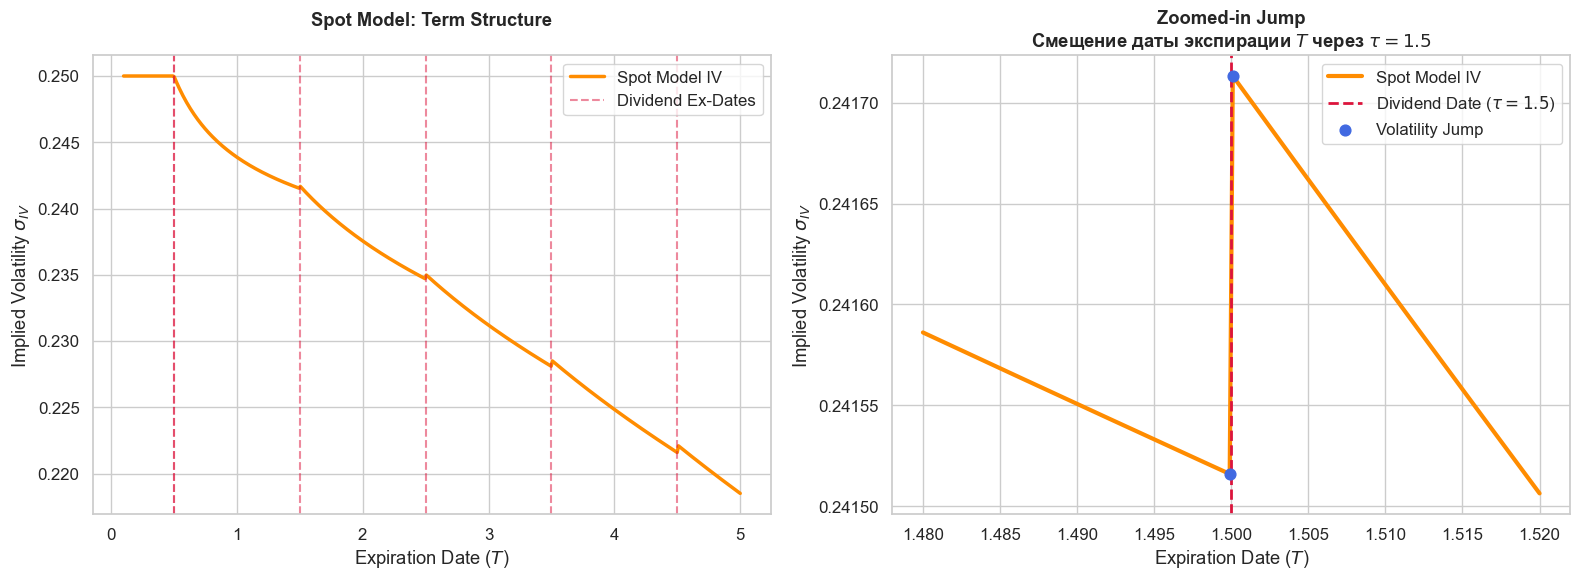

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

tGridFull = np.linspace(0.1, 5.0, 500)
ivSpotFull = []

for tExp in tGridFull:
    pvNear = 0.0
    pvFar = 0.0
    pvPastSpot = 0.0
    
    for tau in tauDivs:
        if tau <= tExp:
            # Bos-Vandermark
            wNear = (tExp - tau) / tExp
            wFar = tau / tExp
            pvNear += wNear * d * np.exp(-r * tau)
            pvFar += wFar * d * np.exp(-r * tau)
            
            pvPastSpot += d * np.exp(r * (tExp - tau))
            
    g = (S0 - pvNear) * np.exp(r * tExp)
    h = -np.exp(r * tExp) * pvFar
    truePrice = black(g, K - h, sigmaTrue, tExp, r, isCall=False)
    
    # Spot Model
    fSpot = S0 * np.exp(r * tExp)
    
    try:
        vol = iv.implied_volatility(truePrice, fSpot, K + pvPastSpot, r, tExp, 'p')
        ivSpotFull.append(vol)
    except:
        ivSpotFull.append(np.nan)

ax1.plot(tGridFull, ivSpotFull, color='darkorange', lw=2.5, label='Spot Model IV')
for tau in tauDivs:
    ax1.axvline(x=tau, color='crimson', linestyle='--', alpha=0.5)

ax1.axvline(x=tauDivs[0], color='crimson', linestyle='--', alpha=0.5, label='Dividend Ex-Dates')

ax1.set_title("Spot Model: Term Structure\n", fontweight='bold')
ax1.set_xlabel("Expiration Date ($T$)")
ax1.set_ylabel("Implied Volatility $\sigma_{IV}$")
ax1.legend()



targetTau = 1.5
tGridZoom = np.linspace(1.48, 1.52, 200)
ivSpotZoom = []

for tExp in tGridZoom:
    pvNear = 0.0
    pvFar = 0.0
    pvPastSpot = 0.0
    
    for tau in tauDivs:
        if tau <= tExp:
            wNear = (tExp - tau) / tExp
            wFar = tau / tExp
            pvNear += wNear * d * np.exp(-r * tau)
            pvFar += wFar * d * np.exp(-r * tau)
            pvPastSpot += d * np.exp(r * (tExp - tau))
            
    g = (S0 - pvNear) * np.exp(r * tExp)
    h = -np.exp(r * tExp) * pvFar
    truePrice = black(g, K - h, sigmaTrue, tExp, r, isCall=False)
    
    fSpot = S0 * np.exp(r * tExp)
    
    try:
        vol = iv.implied_volatility(truePrice, fSpot, K + pvPastSpot, r, tExp, 'p')
        ivSpotZoom.append(vol)
    except:
        ivSpotZoom.append(np.nan)

ax2.plot(tGridZoom, ivSpotZoom, color='darkorange', lw=3, label='Spot Model IV')
ax2.axvline(x=targetTau, color='crimson', linestyle='--', lw=2, label=r'Dividend Date ($\tau=1.5$)')

jumpIdx = np.where(tGridZoom >= targetTau)[0][0]
ax2.scatter([tGridZoom[jumpIdx-1], tGridZoom[jumpIdx]], 
            [ivSpotZoom[jumpIdx-1], ivSpotZoom[jumpIdx]], 
            color='royalblue', zorder=5, s=60, label='Volatility Jump')

ax2.set_title("Zoomed-in Jump\nСмещение даты экспирации $T$ через $\\tau=1.5$", fontweight='bold')
ax2.set_xlabel("Expiration Date ($T$)")
ax2.set_ylabel("Implied Volatility $\sigma_{IV}$")
ax2.legend()

plt.tight_layout()
plt.show()

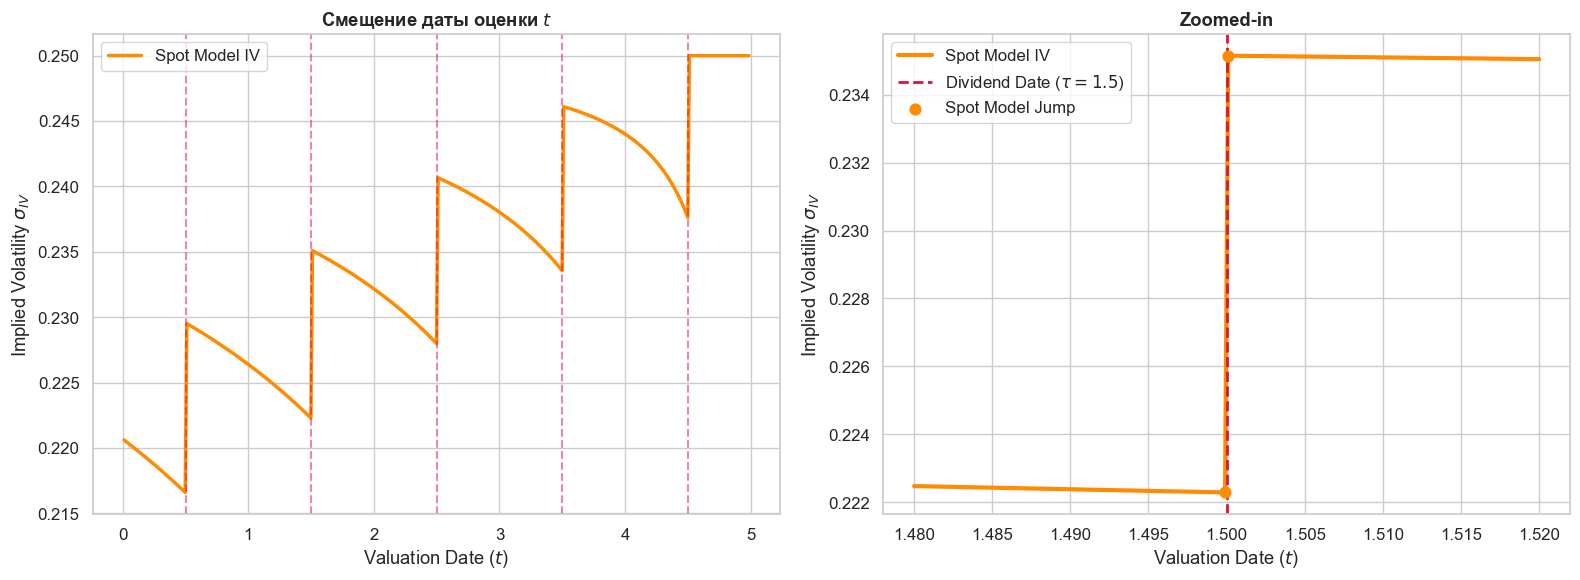

In [51]:
S_base = 100.0  # цена акции, "очищенная" от будущих дивидендов
K = 100.0
r = 0.15
d = 5.0
sigmaTrue = 0.25
T_exp = 5.0    
tauDivs = np.array([0.5, 1.5, 2.5, 3.5, 4.5])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


tValGridFull = np.linspace(0.01, 5, 400)
ivSpot_tFull = []
ivForward_tFull = []
ivBvm_tFull = []

for tVal in tValGridFull:
    S_t = S_base
    for tau in tauDivs:
        if tau > tVal:
            S_t += d * np.exp(-r * (tau - tVal))
            
    tau_rem = T_exp - tVal  # Оставшееся время жизни опциона
    
    pvNear = 0.0
    pvFar = 0.0
    pvFutFwd = 0.0
    fvFutSpot = 0.0  # Будущая стоимость дивидендов (для сдвига страйка в Spot)
    
    for tau in tauDivs:
        if tVal < tau <= T_exp:
            wNear = (T_exp - tau) / tau_rem
            wFar = (tau - tVal) / tau_rem
            pvNear += wNear * d * np.exp(-r * (tau - tVal))
            pvFar += wFar * d * np.exp(-r * (tau - tVal))
            
            pvFutFwd += d * np.exp(-r * (tau - tVal))
            fvFutSpot += d * np.exp(r * (T_exp - tau))
            
    # ЭТАЛОННАЯ ЦЕНА (Bos-Vandermark)
    g = (S_t - pvNear) * np.exp(r * tau_rem)
    h = -np.exp(r * tau_rem) * pvFar
    truePrice = black(g, K - h, sigmaTrue, tau_rem, r, isCall=False)
    
    # Spot Model
    fSpot = S_t * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(truePrice, fSpot, K + fvFutSpot, r, tau_rem, 'p')
        ivSpot_tFull.append(vol)
    except:
        ivSpot_tFull.append(np.nan)


ax1.plot(tValGridFull, ivSpot_tFull, color='darkorange', lw=2.5, label='Spot Model IV')


for tau in tauDivs[:5]: 
    ax1.axvline(x=tau, color='crimson', linestyle='--', alpha=0.5)

ax1.set_title("Смещение даты оценки $t$", fontweight='bold')
ax1.set_xlabel("Valuation Date ($t$)")
ax1.set_ylabel("Implied Volatility $\sigma_{IV}$")
ax1.legend()


# вблизи tau = 1.5

targetTau = 1.5
tValGridZoom = np.linspace(1.48, 1.52, 200)
ivSpot_tZoom = []
ivForward_tZoom = []
ivBvm_tZoom = []

for tVal in tValGridZoom:
    S_t = S_base
    for tau in tauDivs:
        if tau > tVal:
            S_t += d * np.exp(-r * (tau - tVal))
            
    tau_rem = T_exp - tVal
    
    pvNear = 0.0
    pvFar = 0.0
    pvFutFwd = 0.0
    fvFutSpot = 0.0
    
    for tau in tauDivs:
        if tVal < tau <= T_exp:
            wNear = (T_exp - tau) / tau_rem
            wFar = (tau - tVal) / tau_rem
            pvNear += wNear * d * np.exp(-r * (tau - tVal))
            pvFar += wFar * d * np.exp(-r * (tau - tVal))
            pvFutFwd += d * np.exp(-r * (tau - tVal))
            fvFutSpot += d * np.exp(r * (T_exp - tau))
            
    g = (S_t - pvNear) * np.exp(r * tau_rem)
    h = -np.exp(r * tau_rem) * pvFar
    truePrice = black(g, K - h, sigmaTrue, tau_rem, r, isCall=False)
    
    # Spot
    fSpot = S_t * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(truePrice, fSpot, K + fvFutSpot, r, tau_rem, 'p')
        ivSpot_tZoom.append(vol)
    except:
        ivSpot_tZoom.append(np.nan)
        


ax2.plot(tValGridZoom, ivSpot_tZoom, color='darkorange', lw=3, label='Spot Model IV')

ax2.axvline(x=targetTau, color='crimson', linestyle='--', lw=2, label=r'Dividend Date ($\tau=1.5$)')

jumpIdx = np.where(tValGridZoom >= targetTau)[0][0]
ax2.scatter([tValGridZoom[jumpIdx-1], tValGridZoom[jumpIdx]], 
            [ivSpot_tZoom[jumpIdx-1], ivSpot_tZoom[jumpIdx]], 
            color='darkorange', zorder=5, s=60, label='Spot Model Jump')

ax2.set_title("Zoomed-in", fontweight='bold')
ax2.set_xlabel("Valuation Date ($t$)")
ax2.set_ylabel("Implied Volatility $\sigma_{IV}$")
ax2.legend()

plt.tight_layout()
plt.show()


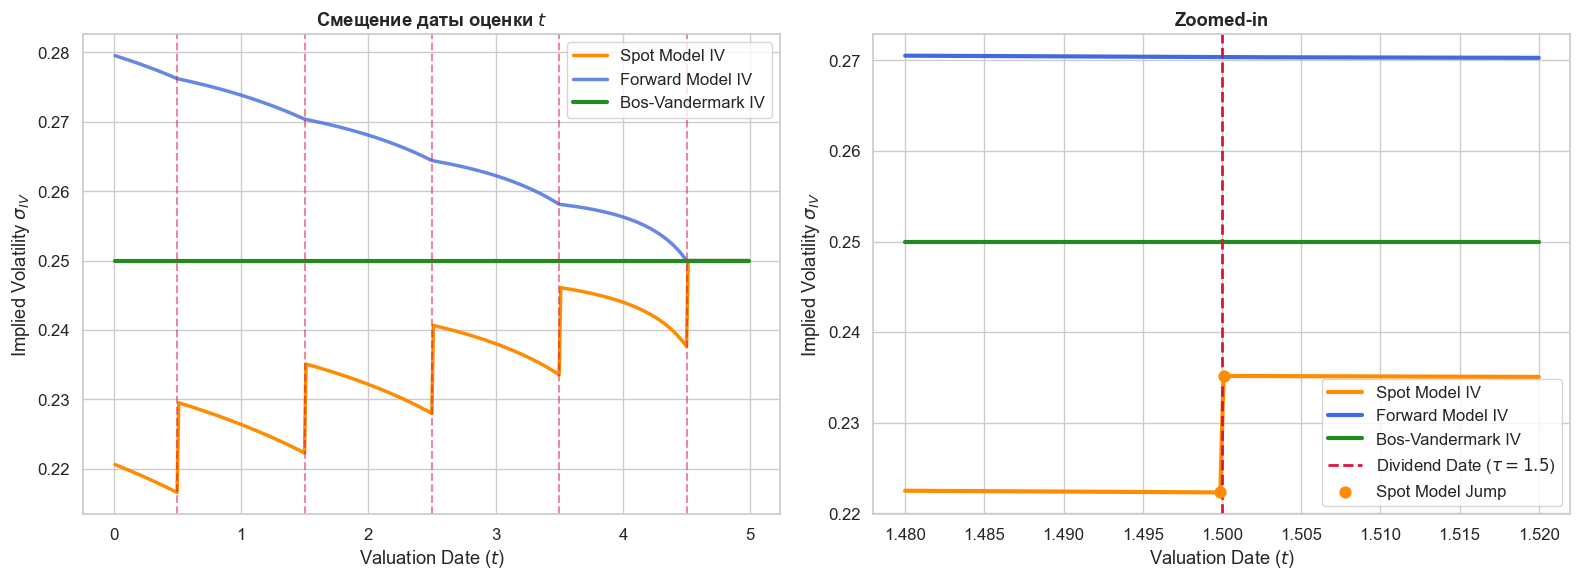

In [52]:
S_base = 100.0  # цена акции, "очищенная" от будущих дивидендов
K = 100.0
r = 0.15
d = 5.0
sigmaTrue = 0.25
T_exp = 5.0    
tauDivs = np.array([0.5, 1.5, 2.5, 3.5, 4.5])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


tValGridFull = np.linspace(0.01, 5, 400)
ivSpot_tFull = []
ivForward_tFull = []
ivBvm_tFull = []

for tVal in tValGridFull:
    S_t = S_base
    for tau in tauDivs:
        if tau > tVal:
            S_t += d * np.exp(-r * (tau - tVal))
            
    tau_rem = T_exp - tVal  # Оставшееся время жизни опциона
    
    pvNear = 0.0
    pvFar = 0.0
    pvFutFwd = 0.0
    fvFutSpot = 0.0  # Будущая стоимость дивидендов (для сдвига страйка в Spot)
    
    for tau in tauDivs:
        if tVal < tau <= T_exp:
            wNear = (T_exp - tau) / tau_rem
            wFar = (tau - tVal) / tau_rem
            pvNear += wNear * d * np.exp(-r * (tau - tVal))
            pvFar += wFar * d * np.exp(-r * (tau - tVal))
            
            pvFutFwd += d * np.exp(-r * (tau - tVal))
            fvFutSpot += d * np.exp(r * (T_exp - tau))
            
    # ЭТАЛОННАЯ ЦЕНА (Bos-Vandermark)
    g = (S_t - pvNear) * np.exp(r * tau_rem)
    h = -np.exp(r * tau_rem) * pvFar
    truePrice = black(g, K - h, sigmaTrue, tau_rem, r, isCall=False)
    
    # Spot Model
    fSpot = S_t * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(truePrice, fSpot, K + fvFutSpot, r, tau_rem, 'p')
        ivSpot_tFull.append(vol)
    except:
        ivSpot_tFull.append(np.nan)
        
    # Forward Model 
    fFwd = (S_t - pvFutFwd) * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(truePrice, fFwd, K, r, tau_rem, 'p')
        ivForward_tFull.append(vol)
    except:
        ivForward_tFull.append(np.nan)
        
    # Bos-Vandermark Model
    fBvm = (S_t - pvNear) * np.exp(r * tau_rem)
    kBvm = K + pvFar * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(truePrice, fBvm, kBvm, r, tau_rem, 'p')
        ivBvm_tFull.append(vol)
    except:
        ivBvm_tFull.append(np.nan)

ax1.plot(tValGridFull, ivSpot_tFull, color='darkorange', lw=2.5, label='Spot Model IV')
ax1.plot(tValGridFull, ivForward_tFull, color='royalblue', lw=2.5, alpha=0.8, label='Forward Model IV')
ax1.plot(tValGridFull, ivBvm_tFull, color='forestgreen', lw=3, label='Bos-Vandermark IV')

for tau in tauDivs[:5]: 
    ax1.axvline(x=tau, color='crimson', linestyle='--', alpha=0.5)

ax1.set_title("Смещение даты оценки $t$", fontweight='bold')
ax1.set_xlabel("Valuation Date ($t$)")
ax1.set_ylabel("Implied Volatility $\sigma_{IV}$")
ax1.legend()


# вблизи tau = 1.5

targetTau = 1.5
tValGridZoom = np.linspace(1.48, 1.52, 200)
ivSpot_tZoom = []
ivForward_tZoom = []
ivBvm_tZoom = []

for tVal in tValGridZoom:
    S_t = S_base
    for tau in tauDivs:
        if tau > tVal:
            S_t += d * np.exp(-r * (tau - tVal))
            
    tau_rem = T_exp - tVal
    
    pvNear = 0.0
    pvFar = 0.0
    pvFutFwd = 0.0
    fvFutSpot = 0.0
    
    for tau in tauDivs:
        if tVal < tau <= T_exp:
            wNear = (T_exp - tau) / tau_rem
            wFar = (tau - tVal) / tau_rem
            pvNear += wNear * d * np.exp(-r * (tau - tVal))
            pvFar += wFar * d * np.exp(-r * (tau - tVal))
            pvFutFwd += d * np.exp(-r * (tau - tVal))
            fvFutSpot += d * np.exp(r * (T_exp - tau))
            
    g = (S_t - pvNear) * np.exp(r * tau_rem)
    h = -np.exp(r * tau_rem) * pvFar
    truePrice = black(g, K - h, sigmaTrue, tau_rem, r, isCall=False)
    
    # Spot
    fSpot = S_t * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(truePrice, fSpot, K + fvFutSpot, r, tau_rem, 'p')
        ivSpot_tZoom.append(vol)
    except:
        ivSpot_tZoom.append(np.nan)
        
    # Forward
    fFwd = (S_t - pvFutFwd) * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(truePrice, fFwd, K, r, tau_rem, 'p')
        ivForward_tZoom.append(vol)
    except:
        ivForward_tZoom.append(np.nan)
        
    # BVM
    fBvm = (S_t - pvNear) * np.exp(r * tau_rem)
    kBvm = K + pvFar * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(truePrice, fBvm, kBvm, r, tau_rem, 'p')
        ivBvm_tZoom.append(vol)
    except:
        ivBvm_tZoom.append(np.nan)

ax2.plot(tValGridZoom, ivSpot_tZoom, color='darkorange', lw=3, label='Spot Model IV')
ax2.plot(tValGridZoom, ivForward_tZoom, color='royalblue', lw=3, label='Forward Model IV')
ax2.plot(tValGridZoom, ivBvm_tZoom, color='forestgreen', lw=3, label='Bos-Vandermark IV')

ax2.axvline(x=targetTau, color='crimson', linestyle='--', lw=2, label=r'Dividend Date ($\tau=1.5$)')

jumpIdx = np.where(tValGridZoom >= targetTau)[0][0]
ax2.scatter([tValGridZoom[jumpIdx-1], tValGridZoom[jumpIdx]], 
            [ivSpot_tZoom[jumpIdx-1], ivSpot_tZoom[jumpIdx]], 
            color='darkorange', zorder=5, s=60, label='Spot Model Jump')

ax2.set_title("Zoomed-in", fontweight='bold')
ax2.set_xlabel("Valuation Date ($t$)")
ax2.set_ylabel("Implied Volatility $\sigma_{IV}$")
ax2.legend()

plt.tight_layout()
plt.show()

Тут честно покажем, что взяв рыночные цены, только третья модель не допускает скачков (колебания улыбки между дивидендными датами наблюдаются в силу шума от монте карло)

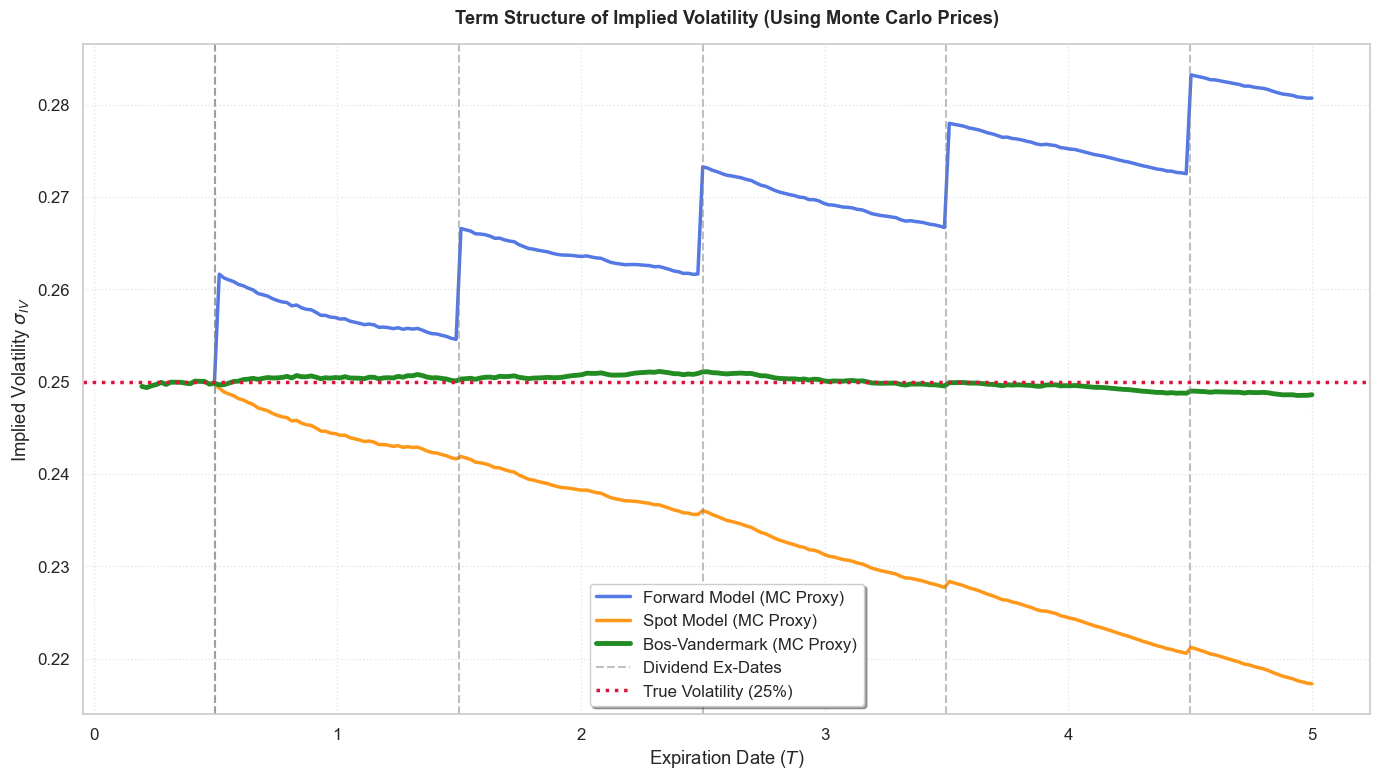

In [ ]:
S0 = 100.0
K = 100.0
r = 0.15
d = 5.0
sigmaTrue = 0.25 
T_max = 5.0
tauDivs = np.array([0.5, 1.5, 2.5, 3.5, 4.5])
stepsPerYear = 252

# sMatrix = stockDynamic(S0, r=0.15, sigma=0.25, nSims=2**17, T=T_max)

# Берем каждый 5-й день, чтобы не считать IV слишком долго
startIdx = int(0.2 * stepsPerYear)
stepIndices = np.arange(startIdx, len(sMatrix), 5)
tGridMC = stepIndices / stepsPerYear

ivForwardMC = []
ivSpotMC = []
ivBvmMC = []

for idx, tExp in zip(stepIndices, tGridMC):
    # срез матрицы цен для текущего шага времени
    sCurrent = sMatrix[idx] 
    payoffs = np.maximum(K - sCurrent, 0) 
    mcPrice = np.exp(-r * tExp) * np.mean(payoffs)
    
    pvNear = 0.0
    pvFar = 0.0
    pvFutFwd = 0.0
    pvPastSpot = 0.0
    
    for tau in tauDivs:
        if tau <= tExp:
            wNear = (tExp - tau) / tExp
            wFar = tau / tExp
            pvNear += wNear * d * np.exp(-r * tau)
            pvFar += wFar * d * np.exp(-r * tau)
            
            pvFutFwd += d * np.exp(-r * tau)
            pvPastSpot += d * np.exp(r * (tExp - tau))
            
    
    #  Forward Model 
    fFwd = (S0 - pvFutFwd) * np.exp(r * tExp)
    try:
        vol = iv.implied_volatility(mcPrice, fFwd, K, r, tExp, 'p')
        ivForwardMC.append(vol)
    except:
        ivForwardMC.append(np.nan)
        
    #  Spot Model 
    fSpot = S0 * np.exp(r * tExp)
    try:
        vol = iv.implied_volatility(mcPrice, fSpot, K + pvPastSpot, r, tExp, 'p')
        ivSpotMC.append(vol)
    except:
        ivSpotMC.append(np.nan)
        
    #  Bos-Vandermark Model 
    fBvm = (S0 - pvNear) * np.exp(r * tExp)
    kBvm = K + pvFar * np.exp(r * tExp)
    try:
        vol = iv.implied_volatility(mcPrice, fBvm, kBvm, r, tExp, 'p')
        ivBvmMC.append(vol)
    except:
        ivBvmMC.append(np.nan)

plt.figure(figsize=(14, 8))

plt.plot(tGridMC, ivForwardMC, color='royalblue', lw=2.5, alpha=0.9, label='Forward Model (MC Proxy)')
plt.plot(tGridMC, ivSpotMC, color='darkorange', lw=2.5, alpha=0.9, label='Spot Model (MC Proxy)')
plt.plot(tGridMC, ivBvmMC, color='forestgreen', lw=3.5, label='Bos-Vandermark (MC Proxy)')

for tau in tauDivs:
    plt.axvline(x=tau, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=tauDivs[0], color='gray', linestyle='--', alpha=0.5, label='Dividend Ex-Dates')

# истинная рыночная волатильность
plt.axhline(y=sigmaTrue, color='crimson', linestyle=':', lw=2.5, label='True Volatility (25%)')

plt.title("Term Structure of Implied Volatility (Using Monte Carlo Prices)", pad=15, fontweight='bold')
plt.xlabel("Expiration Date ($T$)")
plt.ylabel("Implied Volatility $\sigma_{IV}$")

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

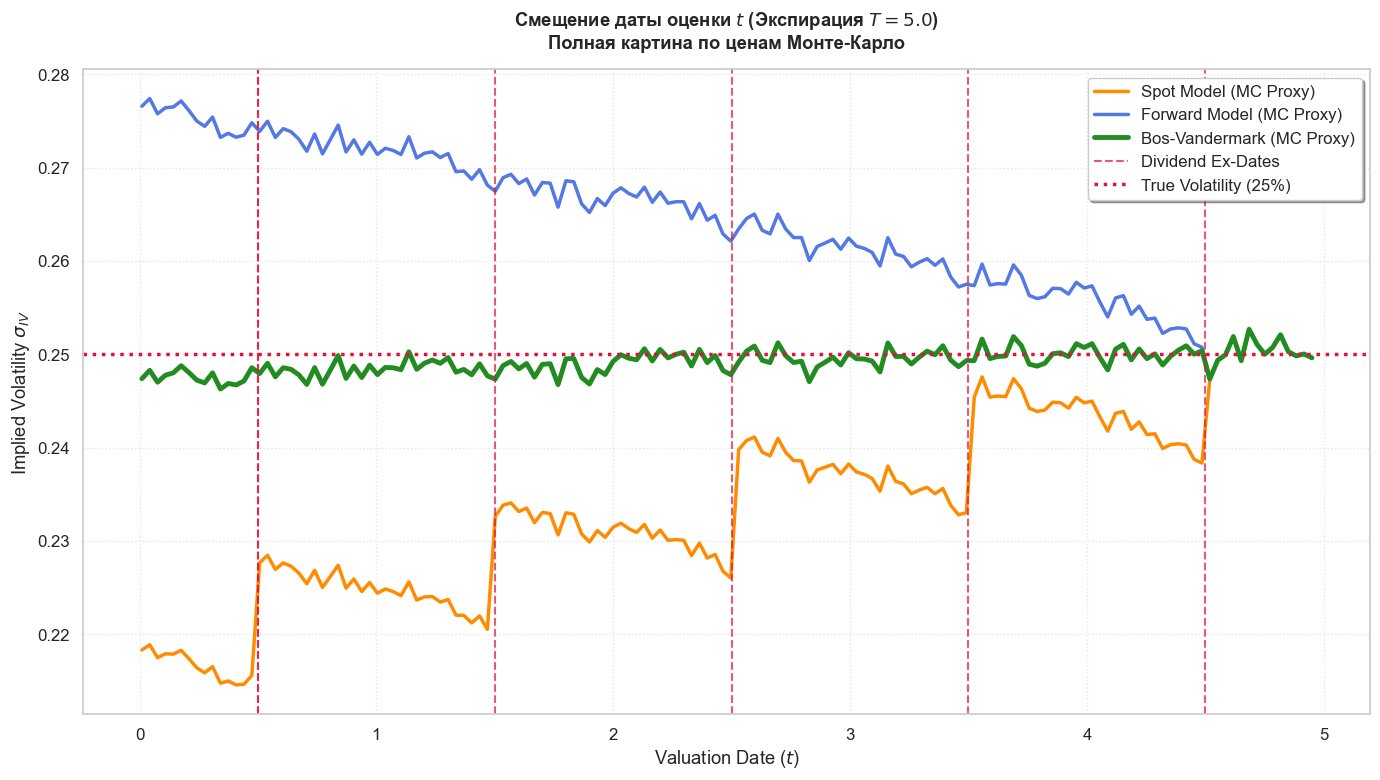

In [ ]:
S_base = 100.0  # Цена акции, очищенная от дивидендов
K = 100.0
r = 0.15
d = 5.0
sigmaTrue = 0.25
T_exp = 5.0     #фикс
tauDivs = np.array([0.5, 1.5, 2.5, 3.5, 4.5])

tValGridFull = np.linspace(0.01, 4.99, 150) 

ivForwardMC_tFull = []
ivSpotMC_tFull = []
ivBvmMC_tFull = []

# Функция для быстрого Монте-Карло на остатке срока (от t до T)
def run_mini_mc(tVal, S_t, T_exp, r, sigma, d, tauDivs, K, nSims=50_000):
    tau_rem = T_exp - tVal
    if tau_rem <= 0: return 0.0
    
    nSteps = max(1, int(tau_rem * 252))
    dt = tau_rem / nSteps
    drift = (r - 0.5 * sigma**2) * dt
    vol = sigma * np.sqrt(dt)
    
    active_taus = [tau for tau in tauDivs if tVal < tau <= T_exp]
    div_steps = [max(1, int((tau - tVal) / tau_rem * nSteps)) for tau in active_taus]
    
    S = np.full(nSims, S_t)
    for i in range(1, nSteps + 1):
        Z = np.random.standard_normal(nSims)
        S = S * np.exp(drift + vol * Z)
        if i in div_steps:
            S = np.maximum(S - d, 1e-4) # Вычет дивиденда
            
    payoffs = np.maximum(K - S, 0)
    return np.exp(-r * tau_rem) * np.mean(payoffs)


for tVal in tValGridFull:
    tau_rem = T_exp - tVal
    
    # рыночный спот (включает премии за все будущие дивиденды)
    S_t = S_base
    for tau in tauDivs:
        if tau > tVal:
            S_t += d * np.exp(-r * (tau - tVal))
        
    mcPrice = run_mini_mc(tVal, S_t, T_exp, r, sigmaTrue, d, tauDivs, K)
    
    pvNear = 0.0
    pvFar = 0.0
    pvFutFwd = 0.0
    fvFutSpot = 0.0 
    
    for tau in tauDivs:
        if tVal < tau <= T_exp:
            wNear = (T_exp - tau) / tau_rem
            wFar = (tau - tVal) / tau_rem
            pvNear += wNear * d * np.exp(-r * (tau - tVal))
            pvFar += wFar * d * np.exp(-r * (tau - tVal))
            
            pvFutFwd += d * np.exp(-r * (tau - tVal))
            fvFutSpot += d * np.exp(r * (T_exp - tau))
            
    # Forward Model 
    fFwd = (S_t - pvFutFwd) * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(mcPrice, fFwd, K, r, tau_rem, 'p')
        ivForwardMC_tFull.append(vol)
    except:
        ivForwardMC_tFull.append(np.nan)
        
    # Spot Model 
    fSpot = S_t * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(mcPrice, fSpot, K + fvFutSpot, r, tau_rem, 'p')
        ivSpotMC_tFull.append(vol)
    except:
        ivSpotMC_tFull.append(np.nan)
        
    # Bos-Vandermark 
    fBvm = (S_t - pvNear) * np.exp(r * tau_rem)
    kBvm = K + pvFar * np.exp(r * tau_rem)
    try:
        vol = iv.implied_volatility(mcPrice, fBvm, kBvm, r, tau_rem, 'p')
        ivBvmMC_tFull.append(vol)
    except:
        ivBvmMC_tFull.append(np.nan)

plt.figure(figsize=(14, 8))

plt.plot(tValGridFull, ivSpotMC_tFull, color='darkorange', lw=2.5, label='Spot Model (MC Proxy)')
plt.plot(tValGridFull, ivForwardMC_tFull, color='royalblue', lw=2.5, alpha=0.9, label='Forward Model (MC Proxy)')
plt.plot(tValGridFull, ivBvmMC_tFull, color='forestgreen', lw=3.5, label='Bos-Vandermark (MC Proxy)')

# Рисуем линии для всех 5 дивидендов
for tau in tauDivs:
    if tau < T_exp:
        plt.axvline(x=tau, color='crimson', linestyle='--', lw=1.5, alpha=0.7)
        
plt.axvline(x=tauDivs[0], color='crimson', linestyle='--', lw=1.5, alpha=0.7, label='Dividend Ex-Dates')
plt.axhline(y=sigmaTrue, color='crimson', linestyle=':', lw=2.5, label='True Volatility (25%)')

plt.title(f"Смещение даты оценки $t$ (Экспирация $T={T_exp}$)\nПолная картина по ценам Монте-Карло", pad=15, fontweight='bold')
plt.xlabel("Valuation Date ($t$)")
plt.ylabel("Implied Volatility $\sigma_{IV}$")

plt.grid(True, which="both", ls=":", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()